# Laboratorio integrador: de textos a patrones con spaCy y TF-IDF
## Pipeline completo con Trafilatura, spaCy, representaciones sparse y visualización analítica

---

## Objetivo
En este cuaderno vas a recorrer un pipeline completo de análisis textual: descargar textos desde la web, organizarlos en una tabla simple, procesarlos con `spaCy`, construir representaciones sparse y usar `TF-IDF` para detectar qué vuelve más distintivo a cada documento.

## Resultados de aprendizaje
Al final de este recorrido deberías poder:

- adquirir un mini corpus real con `trafilatura`;
- organizar ese corpus en un `DataFrame` reutilizable;
- inspeccionar qué información agrega `spaCy` antes de automatizar el análisis;
- construir observables con lemas, entidades y bigramas;
- contrastar `Bag of Words` con `TF-IDF`;
- volver del patrón al fragmento para sostener una lectura interpretativa.

## Relación con los cuadernos anteriores
Este cuaderno junta en un solo flujo varias piezas que venimos trabajando por separado:

- de `002_adquisicion_corpus` retomamos la extracción con `trafilatura`;
- de `003_spacy` retomamos el procesamiento lingüístico con `spaCy`;
- de `005_vectorizacion` retomamos el paso a `Bag of Words`, `TF-IDF` y bigramas;
- hacia adelante, este laboratorio te prepara para formular análisis comparados y trabajos integradores con un pipeline completo de punta a punta.


## Pregunta guía y corpus de trabajo

La idea central no es reemplazar la lectura por tablas o gráficos. La idea es usar una **lectura distante** para detectar recurrencias y contrastes, y después volver al texto para mirar cómo funcionan esos términos en contexto.

Vamos a trabajar con tres textos de **Valentín Muro** publicados en **Cenital**. El corpus es pequeño, comparable y temáticamente consistente: inteligencia artificial, ciencia, lectura y cognición. Eso nos permite hacer dos cosas a la vez:

- mirar patrones de conjunto;
- volver con facilidad a fragmentos concretos.

En la parte visual vamos a sostener un criterio sobrio: pocos gráficos, rótulos claros, color con jerarquía y nada de ornamentación innecesaria.


## 1. Preparación del entorno

Antes de tocar el corpus, cargamos las herramientas de trabajo.

- `trafilatura` nos ayuda a aislar el contenido principal de una URL.
- `spaCy` construye observables lingüísticos sobre cada texto.
- `CountVectorizer` y `TfidfVectorizer` convierten texto en matrices sparse.
- `pandas` organiza la información en tablas.
- `matplotlib` y `seaborn` nos permiten comparar resultados con gráficos sobrios y legibles.


In [12]:
import sys
print(sys.executable)

c:\Tecnicas_habla\ifts24-lab-pln-2026\.venv\Scripts\python.exe


In [1]:
# --- Importaciones necesarias ---
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import trafilatura

# Configuramos un estilo visual limpio y consistente para todo el cuaderno
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")

# Ampliamos el ancho visible de las columnas textuales
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado correctamente.")


Entorno cargado correctamente.


Definimos ahora las fuentes del corpus y algunos parámetros generales. Cada entrada incluye un **texto de respaldo** por si la descarga web falla. Ese respaldo sirve solo para sostener la adquisición del corpus: el análisis lingüístico posterior se hace siempre con `spaCy`.


In [2]:
# --- Fuentes del corpus ---
FUENTES = [
    {
        "id": "muro_ia_cancer",
        "fecha": "2026-03-19",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "No, ChatGPT no hizo una vacuna contra el cáncer",
        "url": "https://cenital.com/no-chatgpt-no-hizo-una-vacuna-contra-el-cancer/",
        "texto_respaldo": "El texto cuestiona la exageración tecnosolucionista alrededor de la IA en biomedicina. Sostiene que los chatbots pueden asistir la búsqueda y la organización de información, pero no reemplazan la validación experimental, la infraestructura científica ni el trabajo de laboratorio.",
    },
    {
        "id": "muro_resumenes",
        "fecha": "2026-03-05",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "Te lo resumo así nomás: cuando la IA no ayuda",
        "url": "https://cenital.com/te-lo-resumo-asi-nomas-cuando-la-ia-no-ayuda/",
        "texto_respaldo": "El texto discute cómo los resúmenes automáticos prometen eficiencia a costa de reducir la fricción cognitiva. La crítica no se limita a los errores fácticos: también apunta al riesgo de delegar el esfuerzo de leer, dudar y construir comprensión propia.",
    },
    {
        "id": "muro_cerebro",
        "fecha": "2025-12-11",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "El cerebro tal vez no sea una computadora",
        "url": "https://cenital.com/el-cerebro-tal-vez-no-sea-una-computadora/",
        "texto_respaldo": "El texto revisa la analogía entre cerebro y computadora. Reconoce su productividad histórica, pero marca sus límites para pensar la cognición, la biología y la materialidad del cerebro como un sistema evolutivo, continuo y encarnado.",
    },
]

# --- Parámetros generales ---
USAR_TEXTO_RESPALDO_SI_FALLA_DESCARGA = True
MODELO_SPACY = "es_core_news_sm"
TOP_N = 10
TOP_N_HEATMAP = 4
VENTANA_FRAGMENTO = 140

cantidad_fuentes = len(FUENTES)
print(f"Fuentes definidas: {cantidad_fuentes}")


Fuentes definidas: 3


## 2. spaCy como condición del flujo

En este cuaderno no vamos a trabajar con una versión "sin spaCy". La decisión metodológica es explícita: queremos que todo el pipeline use el mismo procesador lingüístico.

Si el modelo no está instalado, el cuaderno se detiene con un mensaje claro. Eso evita mezclar resultados heterogéneos o degradar el análisis con atajos que no forman parte del trabajo de la unidad.


In [4]:
import spacy
nlp = spacy.load("es_core_news_sm")
print("spaCy OK")

spaCy OK


In [5]:
# Importamos spaCy recién acá para separar entorno general y procesamiento lingüístico
import spacy

# Intentamos cargar el modelo de español que usamos en la cursada
try:
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    mensaje_error = (
        "No se pudo cargar spaCy. Este cuaderno trabaja siempre con spaCy. "
        "Instalá el modelo con `python -m spacy download es_core_news_sm` "
        "y volvé a ejecutar desde el inicio."
    )
    raise RuntimeError(mensaje_error) from error

# Aseguramos que 'él' funcione como stopword en sus variantes más comunes
variantes_el = ["él", "Él", "ÉL"]
for i in range(len(variantes_el)):
    variante = variantes_el[i]
    nlp.vocab[variante].is_stop = True

nombre_modelo = nlp.meta["name"]
pipeline_activo = nlp.pipe_names
print(f"Modelo cargado: {nombre_modelo}")
print(f"Pipeline activo: {pipeline_activo}")


Modelo cargado: core_news_sm
Pipeline activo: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 3. Adquisición mínima con Trafilatura

Acá usamos la adquisición de forma instrumental: lo suficiente para descargar, limpiar y guardar el texto principal de cada artículo.

El flujo tiene dos pasos muy simples:

1. `fetch_url()` descarga el HTML.
2. `extract()` intenta quedarse con el contenido principal y descartar el ruido de interfaz.

Si alguna URL falla, usamos el texto de respaldo definido más arriba para que el resto del pipeline siga siendo ejecutable en clase.


In [6]:
def extraer_texto_principal(url):
    """Descarga una URL y devuelve el texto principal usando Trafilatura."""
    descargado = trafilatura.fetch_url(url)
    if not descargado:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
        return None

    texto_extraido = trafilatura.extract(
        descargado,
        include_comments=False,
        include_tables=False,
        favor_precision=True,
    )
    return texto_extraido


# Recorremos las fuentes y armamos una primera colección de registros crudos (contruccion del corpus)
registros_crudos = []
for i in range(len(FUENTES)):                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       
    fuente = FUENTES[i]
    texto_extraido = extraer_texto_principal(fuente["url"])
    origen_texto = "web"

    # Si la descarga falla, usamos el texto de respaldo definido para esa fuente
    if not texto_extraido and USAR_TEXTO_RESPALDO_SI_FALLA_DESCARGA:
        texto_extraido = fuente["texto_respaldo"]
        origen_texto = "respaldo"

    registro = {
        "id": fuente["id"],
        "fecha": fuente["fecha"],
        "medio": fuente["medio"],
        "autor": fuente["autor"],
        "titulo": fuente["titulo"],
        "url": fuente["url"],
        "texto": texto_extraido,
        "origen_texto": origen_texto,
    }
    registros_crudos.append(registro)

cantidad_registros = len(registros_crudos)
print(f"Registros recuperados: {cantidad_registros}")


Registros recuperados: 3


Ahora transformamos esa lista de diccionarios en una tabla de trabajo. Este paso importa porque nos deja el corpus en un formato reutilizable para el resto del análisis.


In [7]:
# Convertimos la colección cruda en un DataFrame de trabajo
tabla_corpus = pd.DataFrame(registros_crudos)

# Validamos que cada fila conserve un texto no vacío
mascara_textos_validos = []
for i in range(len(tabla_corpus)):
    texto_actual = tabla_corpus.at[i, "texto"]

    if pd.isna(texto_actual):
        mascara_textos_validos.append(False)
    else:
        texto_limpio = str(texto_actual).strip()
        texto_valido = texto_limpio != ""
        mascara_textos_validos.append(texto_valido)

tabla_corpus = tabla_corpus[mascara_textos_validos].reset_index(drop=True)

cantidad_documentos = len(tabla_corpus)
if cantidad_documentos == 0:
    raise ValueError("No quedó ningún documento con texto utilizable. Revisá las URLs o los textos de respaldo.")

# Normalizamos la fecha para que quede disponible como dato temporal
tabla_corpus["fecha"] = pd.to_datetime(tabla_corpus["fecha"], errors="coerce")

# Creamos etiquetas cortas para usar después en tablas y gráficos
etiquetas_cortas = []
for i in range(len(tabla_corpus)):
    numero_documento = i + 1
    etiqueta = f"Texto {numero_documento}"
    etiquetas_cortas.append(etiqueta)
tabla_corpus["titulo_corto"] = etiquetas_cortas

# Contamos palabras aproximadas usando un patrón de letras Unicode
patron_palabras = re.compile(r"\b[^\W\d_]{2,}\b", flags=re.UNICODE)
cantidades_palabras = []
for i in range(len(tabla_corpus)):
    texto_actual = tabla_corpus.at[i, "texto"]
    palabras_encontradas = patron_palabras.findall(str(texto_actual))
    cantidad_palabras = len(palabras_encontradas)
    cantidades_palabras.append(cantidad_palabras)
tabla_corpus["num_palabras"] = cantidades_palabras

print(f"Documentos disponibles: {cantidad_documentos}")
display(tabla_corpus[["id", "fecha", "medio", "autor", "titulo", "origen_texto", "num_palabras"]])


Documentos disponibles: 3


,id,fecha,medio,autor,titulo,origen_texto,num_palabras
0,muro_ia_cancer,2026-03-19,Cenital,Valentín Muro,"No, ChatGPT no hizo una vacuna contra el cáncer",web,1622
1,muro_resumenes,2026-03-05,Cenital,Valentín Muro,Te lo resumo así nomás: cuando la IA no ayuda,web,1625
2,muro_cerebro,2025-12-11,Cenital,Valentín Muro,El cerebro tal vez no sea una computadora,web,1537


Esta tabla ya deja ver dos decisiones importantes del pipeline:

- el corpus quedó estructurado, no disperso en variables sueltas;
- cada documento conserva metadatos mínimos que después te permiten volver a la fuente original.

Antes de modelizar, conviene hacer una auditoría rápida del recorte: cuántos textos hay, qué tan largos son y si el conjunto se ve razonablemente equilibrado.


In [8]:
# Armamos una tabla breve de resumen del corpus
registros_resumen = []

total_palabras = int(tabla_corpus["num_palabras"].sum())
promedio_palabras = round(float(tabla_corpus["num_palabras"].mean()), 1)
medio_corpus = tabla_corpus.at[0, "medio"]
autor_corpus = tabla_corpus.at[0, "autor"]

registros_resumen.append({"métrica": "documentos", "valor": len(tabla_corpus)})
registros_resumen.append({"métrica": "palabras aproximadas", "valor": total_palabras})
registros_resumen.append({"métrica": "promedio por texto", "valor": promedio_palabras})
registros_resumen.append({"métrica": "medio", "valor": medio_corpus})
registros_resumen.append({"métrica": "autor", "valor": autor_corpus})

tabla_resumen_corpus = pd.DataFrame(registros_resumen)
display(tabla_resumen_corpus)


,métrica,valor
0,documentos,3
1,palabras aproximadas,4784
2,promedio por texto,1594.7
3,medio,Cenital
4,autor,Valentín Muro


La tabla resumen condensa el recorte. El gráfico siguiente agrega una lectura más inmediata: te permite comparar de un vistazo qué tan largos quedaron los textos y detectar si alguno domina al resto por volumen.


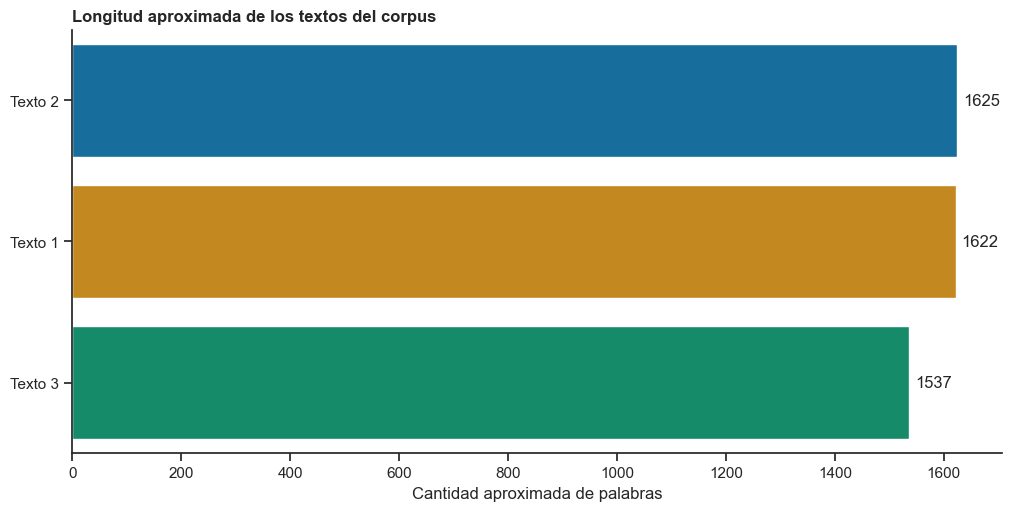

In [9]:
# Ordenamos los documentos por longitud para visualizarlos mejor
tabla_longitudes = tabla_corpus.copy()
tabla_longitudes = tabla_longitudes.sort_values("num_palabras", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=tabla_longitudes,
    x="num_palabras",
    y="titulo_corto",
    hue="titulo_corto",
    palette="colorblind",
    legend=False,
    ax=ax,
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f", padding=4)

ax.set_title("Longitud aproximada de los textos del corpus", loc="left", fontweight="bold")
ax.set_xlabel("Cantidad aproximada de palabras")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


Esta primera auditoría no interpreta el discurso todavía, pero sí te permite detectar si el recorte quedó demasiado desbalanceado. En un corpus chico, esta verificación es importante: una gran diferencia de longitud puede empujar conteos y visualizaciones de manera engañosa.


## 4. Paso intermedio: mirar cómo spaCy lee un fragmento

Antes de automatizar el procesamiento de todo el corpus, conviene detenerse en una muestra corta. El objetivo de esta sección es ver **qué información agrega `spaCy` por token**.

Vamos a mirar un fragmento del primer documento y a inspeccionar, token por token:

- la forma original;
- el lema;
- si `spaCy` lo considera stopword;
- si es alfabético;
- su categoría gramatical;
- y, cuando corresponda, si forma parte de una entidad.


In [10]:
# Tomamos un fragmento corto del primer documento para inspección manual
texto_muestra = tabla_corpus.at[0, "texto"]
fragmento_muestra = texto_muestra[:420]

# Procesamos solo ese fragmento con spaCy
doc_muestra = nlp(fragmento_muestra)

# Construimos una tabla corta para mirar token por token
registros_tokens = []
limite_tokens = 18
contador_tokens = 0

for token in doc_muestra:
    if contador_tokens >= limite_tokens:
        break

    lema_token = token.lemma_.strip().lower()
    if lema_token == "" or lema_token == "-pron-":
        lema_token = token.text.lower()

    entidad_token = token.ent_type_
    if entidad_token == "":
        entidad_token = "-"

    registro_token = {
        "token": token.text,
        "lema": lema_token,
        "es_stopword": token.is_stop,
        "es_alfabético": token.is_alpha,
        "pos": token.pos_,
        "entidad": entidad_token,
    }
    registros_tokens.append(registro_token)
    contador_tokens = contador_tokens + 1

tabla_tokens_muestra = pd.DataFrame(registros_tokens)

print("Primeros tokens del fragmento de muestra")
display(tabla_tokens_muestra)


Primeros tokens del fragmento de muestra


,token,lema,es_stopword,es_alfabético,pos,entidad
0,Mientras,mientras,True,True,SCONJ,-
1,los,el,True,True,DET,-
2,simples,simple,False,True,ADJ,-
3,mortales,mortal,False,True,NOUN,-
4,usamos,usamo,True,True,ADJ,-
5,ChatGPT,chatgpt,False,True,VERB,MISC
6,para,para,True,True,ADP,-
7,escribir,escribir,False,True,VERB,-
8,un,uno,True,True,DET,-
9,correo,correo,False,True,NOUN,-


Esta tabla muestra algo clave para el resto del cuaderno: `spaCy` no solo divide el texto en tokens. También agrega capas de información que después podemos reutilizar para contar, filtrar, agrupar y volver al texto.

Fijate además en un límite que ya vimos en la unidad de `spaCy`: la lematización en español rioplatense no siempre es perfecta, sobre todo cuando aparecen formas de voseo. Eso no invalida el pipeline, pero sí obliga a leer los resultados con criterio.


## 5. Procesamiento lingüístico del corpus completo

Ahora escalamos el mismo procedimiento al corpus entero. Para cada documento vamos a construir tres capas de trabajo:

- `texto_lemas`: todos los lemas del documento;
- `texto_contenido`: solo palabras alfabéticas y no stopwords;
- `entidades`: una lista de entidades nombradas detectadas por `spaCy`.

Después vamos a usar `texto_contenido` como base para la vectorización, porque concentra mejor las palabras con mayor carga semántica.


In [11]:
def normalizar_lemma(token):
    """Obtiene un lema utilizable para el token recibido."""
    lema = token.lemma_.strip().lower()
    if lema == "" or lema == "-pron-":
        lema = token.text.lower()
    return lema

# Algunos lemas pueden colarse por decisiones del modelo aunque no sirvan
# para el análisis de contenido que buscamos en este cuaderno.
LEMAS_EXCLUIDOS = ["él"]


def limpiar_texto_para_modelo(texto, terminos_excluidos):
    """Elimina términos excluidos de un texto ya separado por espacios."""
    tokens = str(texto).split()
    tokens_limpios = []

    for i in range(len(tokens)):
        token = tokens[i]
        if token not in terminos_excluidos:
            tokens_limpios.append(token)

    texto_limpio = " ".join(tokens_limpios)
    return texto_limpio


def armar_resumen_entidades(lista_entidades):
    """Convierte una lista de entidades en un resumen legible."""
    if len(lista_entidades) == 0:
        return "Sin entidades detectadas"

    partes = []
    for i in range(len(lista_entidades)):
        entidad = lista_entidades[i]
        texto_entidad = entidad["texto"]
        etiqueta_entidad = entidad["etiqueta"]
        parte = f"{texto_entidad} [{etiqueta_entidad}]"
        partes.append(parte)

    resumen = ", ".join(partes)
    return resumen


# Reunimos todos los textos del corpus para procesarlos en lote con spaCy
textos_corpus = []
for i in range(len(tabla_corpus)):
    texto_actual = tabla_corpus.at[i, "texto"]
    textos_corpus.append(texto_actual)

registros_linguisticos = []
for doc in nlp.pipe(textos_corpus, batch_size=8):
    lemas = []
    contenido = []
    entidades = []

    numero_oraciones = 0
    for _ in doc.sents:
        numero_oraciones = numero_oraciones + 1

    for token in doc:
        if token.is_space:
            continue

        lema = normalizar_lemma(token)
        lemas.append(lema)

        es_alfabetico = token.is_alpha
        es_stopword = token.is_stop
        lema_excluido = lema in LEMAS_EXCLUIDOS

        if es_alfabetico and not es_stopword and not lema_excluido:
            contenido.append(lema)

    for entidad in doc.ents:
        registro_entidad = {
            "texto": entidad.text,
            "etiqueta": entidad.label_,
        }
        entidades.append(registro_entidad)

    texto_lemas = " ".join(lemas)
    texto_contenido = " ".join(contenido)

    resumen_entidades = armar_resumen_entidades(entidades)

    registro_linguistico = {
        "texto_lemas": texto_lemas,
        "texto_contenido": texto_contenido,
        "entidades": entidades,
        "entidades_resumen": resumen_entidades,
        "num_oraciones": numero_oraciones,
    }
    registros_linguisticos.append(registro_linguistico)

tabla_linguistica = pd.DataFrame(registros_linguisticos)
tabla_corpus = pd.concat([tabla_corpus.reset_index(drop=True), tabla_linguistica], axis=1)

# Dejamos texto_modelo como columna explicita del corpus para las secciones siguientes
textos_modelo = []
for i in range(len(tabla_corpus)):
    texto_contenido_actual = tabla_corpus.at[i, "texto_contenido"]
    texto_lemas_actual = tabla_corpus.at[i, "texto_lemas"]

    texto_contenido_modelo = limpiar_texto_para_modelo(texto_contenido_actual, LEMAS_EXCLUIDOS)
    texto_lemas_modelo = limpiar_texto_para_modelo(texto_lemas_actual, LEMAS_EXCLUIDOS)

    texto_modelo = texto_contenido_modelo
    if texto_modelo.strip() == "":
        texto_modelo = texto_lemas_modelo

    textos_modelo.append(texto_modelo)

tabla_corpus["texto_modelo"] = textos_modelo

display(tabla_corpus[["titulo_corto", "num_oraciones", "texto_contenido", "texto_modelo", "entidades_resumen"]])


,titulo_corto,num_oraciones,texto_contenido,texto_modelo,entidades_resumen
0,Texto 1,61,simple mortal chatgpt escribir correo resumir fiaca leer emprendedor tecnológico australiano usar curar cáncer perro historia circular rápidamente impulsado...,simple mortal chatgpt escribir correo resumir fiaca leer emprendedor tecnológico australiano usar curar cáncer perro historia circular rápidamente impulsado...,"ChatGPT [MISC], Greg Brockman [PER], OpenAI [MISC], Sam Altman [PER], Silicon Valley [LOC], Fascinante [PER], The Australian [PER], Paul Conyngham [PER], Ro..."
1,Texto 2,79,famoso episodio seinfeld george anotar club lectura pensar él leer breakfast at librito doscientos página pasar jerry preguntar george balbucear leístar pág...,famoso episodio seinfeld george anotar club lectura pensar leer breakfast at librito doscientos página pasar jerry preguntar george balbucear leístar página...,"Seinfeld [MISC], George [PER], Solo debe leer [MISC], Breakfast at Tiffany’s [MISC], Jerry [PER], George [PER], ¿verdad? [MISC], Jerry [PER], George [PER], ..."
2,Texto 3,57,analogía máquina actividad neuronal convencer confesar psicólogo conductual karl lashley american neurological association junio basar sencillo observación ...,analogía máquina actividad neuronal convencer confesar psicólogo conductual karl lashley american neurological association junio basar sencillo observación ...,"Karl Lashley [PER], American Neurological Association [ORG], Descartes [PER], De allí tomó la inspiración [MISC], Mesmer [MISC], Galvani [PER], Volta [PER],..."


La columna más importante para lo que sigue es `texto_modelo`: ahí quedó el texto ya reducido a una representación más útil para conteos y ponderaciones. No es el texto original, pero tampoco es un número todavía. Es una **capa intermedia** entre lenguaje y modelización.


## 6. Observables iniciales del corpus

Acá empieza la lectura distante. Todavía no estamos preguntando "qué significa todo esto", sino algo un poco más acotado:

- qué palabras reaparecen;
- qué entidades se vuelven visibles;
- qué asociaciones aparecen cuando dejamos de mirar palabras sueltas.


In [13]:
# Reunimos todo el texto modelo del corpus en un único bloque para contar términos
texto_modelo_total = ""
for i in range(len(tabla_corpus)):
    texto_modelo_actual = tabla_corpus.at[i, "texto_modelo"]

    if texto_modelo_total == "":
        texto_modelo_total = texto_modelo_actual
    else:
        texto_modelo_total = texto_modelo_total + " " + texto_modelo_actual

lista_terminos_crudos = texto_modelo_total.split()
lista_terminos_corpus = []
for i in range(len(lista_terminos_crudos)):
    termino = lista_terminos_crudos[i]
    if termino not in LEMAS_EXCLUIDOS:
        lista_terminos_corpus.append(termino)
contador_terminos = Counter(lista_terminos_corpus)
pares_top_terminos = contador_terminos.most_common(TOP_N)

registros_top_terminos = []
for i in range(len(pares_top_terminos)):
    par = pares_top_terminos[i]
    termino = par[0]
    frecuencia = par[1]
    registro = {
        "termino": termino,
        "frecuencia": frecuencia,
    }
    registros_top_terminos.append(registro)

tabla_top_terminos = pd.DataFrame(registros_top_terminos)

print("Términos de contenido más frecuentes en el corpus")
display(tabla_top_terminos)


Términos de contenido más frecuentes en el corpus


,termino,frecuencia
0,cerebro,23
1,resumen,16
2,computadora,16
3,humano,15
4,metáfora,12
5,leer,11
6,pasar,11
7,herramienta,11
8,problema,11
9,máquina,11


Este ranking te muestra recurrencias, pero todavía no distingue entre lo **frecuente** y lo **distintivo**. Un término puede aparecer mucho y, al mismo tiempo, no servir para diferenciar documentos.


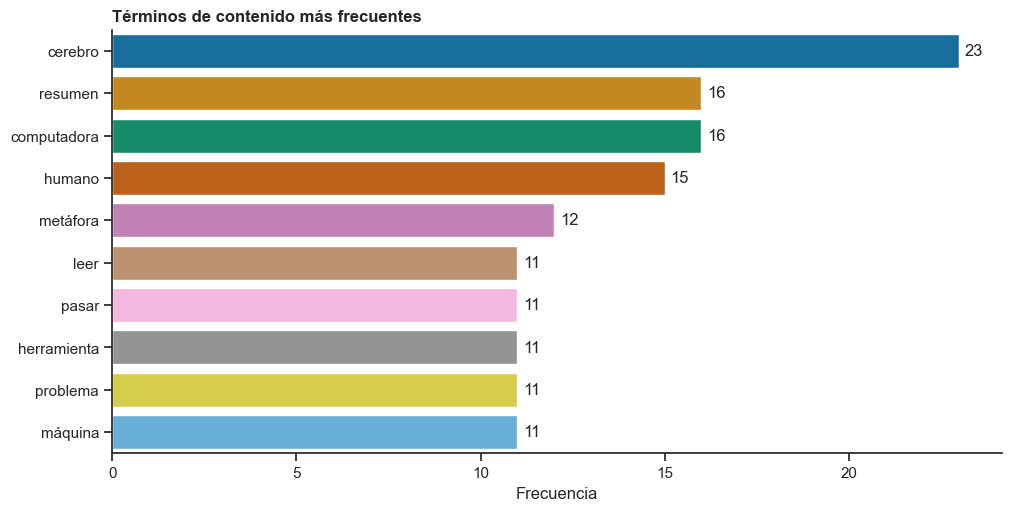

In [14]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=tabla_top_terminos,
    x="frecuencia",
    y="termino",
    hue="termino",
    palette="colorblind",
    legend=False,
    ax=ax,
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f", padding=4)

ax.set_title("Términos de contenido más frecuentes", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


El gráfico ayuda a comparar rápido, pero seguí leyendo con cautela: una frecuencia alta no equivale automáticamente a una afirmación discursiva central. Para eso necesitamos más contexto y, enseguida, una medida de distintividad.


In [15]:
# Desagregamos las entidades documento por documento
registros_entidades = []
for i in range(len(tabla_corpus)):
    documento = tabla_corpus.at[i, "titulo_corto"]
    lista_entidades = tabla_corpus.at[i, "entidades"]

    for j in range(len(lista_entidades)):
        entidad = lista_entidades[j]
        registro_entidad = {
            "documento": documento,
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        }
        registros_entidades.append(registro_entidad)

tabla_entidades = pd.DataFrame(registros_entidades)

if len(tabla_entidades) == 0:
    tabla_top_entidades = pd.DataFrame(columns=["texto_entidad", "etiqueta", "frecuencia"])
    print("No se detectaron entidades suficientes para construir una tabla comparativa.")
else:
    tabla_conteo_entidades = (
        tabla_entidades.groupby(["texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
    )
    tabla_conteo_entidades = tabla_conteo_entidades.sort_values("frecuencia", ascending=False)
    tabla_conteo_entidades = tabla_conteo_entidades.reset_index(drop=True)
    tabla_top_entidades = tabla_conteo_entidades.head(TOP_N)
    print("Entidades más visibles en el corpus")
    display(tabla_top_entidades)


Entidades más visibles en el corpus


,texto_entidad,etiqueta,frecuencia
0,ChatGPT,MISC,5
1,Rosie,PER,5
2,Conyngham,PER,4
3,Google,ORG,4
4,Por eso,MISC,4
5,Cenital,LOC,3
6,AlphaFold,MISC,3
7,¿,LOC,3
8,IA,LOC,3
9,Receta,PER,3


Las entidades sirven para detectar quiénes, qué instituciones o qué objetos de referencia aparecen en la serie. Son útiles para orientar la lectura, pero también pueden cometer errores o fragmentar nombres de maneras poco felices. Por eso conviene usarlas como pista, no como verdad cerrada.


Bigramas más frecuentes del corpus


,bigrama,frecuencia
0,inteligencia artificial,8
1,cerebro computadora,6
2,cognición humano,3
3,desastre podés,3
4,leés cenital,3
5,mano seguir,3
6,pasar pedir,3
7,despabilar lector,3
8,difícil periodismo,3
9,pedir dser,3


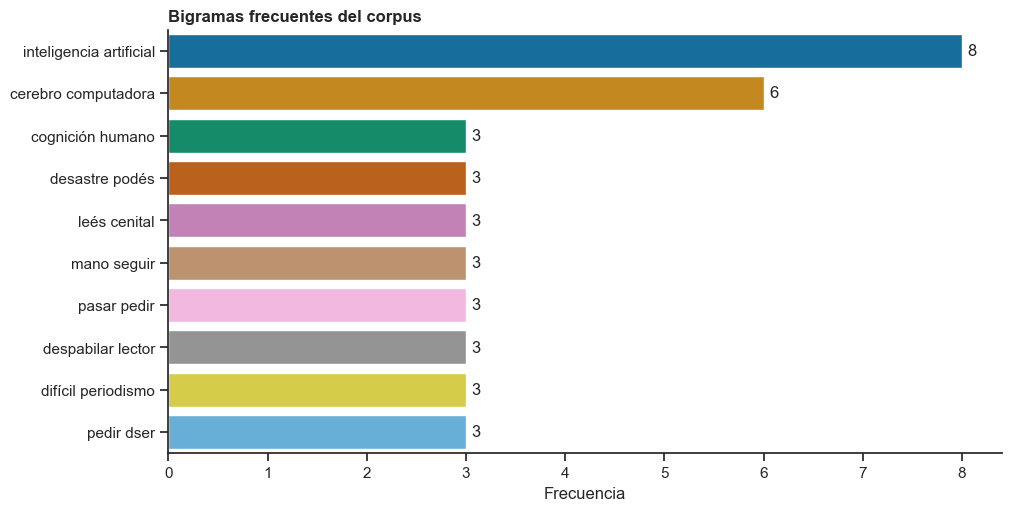

In [16]:
# Construimos bigramas para captar asociaciones de dos palabras
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(tabla_corpus["texto_modelo"])

nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
sumas_bigramas = matriz_bigramas.sum(axis=0)
frecuencias_bigramas = sumas_bigramas.A1

registros_bigramas = []
for i in range(len(nombres_bigramas)):
    bigrama = nombres_bigramas[i]
    frecuencia = int(frecuencias_bigramas[i])
    registro_bigrama = {
        "bigrama": bigrama,
        "frecuencia": frecuencia,
    }
    registros_bigramas.append(registro_bigrama)

tabla_bigramas = pd.DataFrame(registros_bigramas)
tabla_bigramas = tabla_bigramas.sort_values("frecuencia", ascending=False)
tabla_bigramas = tabla_bigramas.reset_index(drop=True)
tabla_top_bigramas = tabla_bigramas.head(TOP_N)

print("Bigramas más frecuentes del corpus")
display(tabla_top_bigramas)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=tabla_top_bigramas,
    x="frecuencia",
    y="bigrama",
    hue="bigrama",
    palette="colorblind",
    legend=False,
    ax=ax,
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.0f", padding=4)

ax.set_title("Bigramas frecuentes del corpus", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()


Los bigramas ayudan a ver algo que los términos sueltos no capturan bien: asociaciones relativamente estables. En un corpus pequeño, suelen ser una buena bisagra entre la lectura de frecuencias y la lectura más fina de `TF-IDF`.


## 7. De los conteos a la distintividad: Bag of Words y TF-IDF

Hasta acá contamos ocurrencias. Eso sirve para ver volumen, pero no alcanza para responder una pregunta decisiva: **qué términos vuelven más singular a cada documento**.

Recordá la diferencia:

- **Bag of Words** cuenta apariciones;
- **TF-IDF** pondera más alto las palabras frecuentes en un documento pero raras en el resto.

En un corpus comparativo, esa diferencia es clave porque separa lo simplemente repetido de lo verdaderamente distintivo.


In [17]:
# Preparamos una tabla de unidades de análisis: un documento por fila
registros_unidades = []
for i in range(len(tabla_corpus)):
    unidad = tabla_corpus.at[i, "titulo_corto"]
    texto_modelo = tabla_corpus.at[i, "texto_modelo"]
    registro_unidad = {
        "unidad": unidad,
        "texto_modelo": texto_modelo,
    }
    registros_unidades.append(registro_unidad)

tabla_unidades = pd.DataFrame(registros_unidades)
display(tabla_unidades)


,unidad,texto_modelo
0,Texto 1,simple mortal chatgpt escribir correo resumir fiaca leer emprendedor tecnológico australiano usar curar cáncer perro historia circular rápidamente impulsado...
1,Texto 2,famoso episodio seinfeld george anotar club lectura pensar leer breakfast at librito doscientos página pasar jerry preguntar george balbucear leístar página...
2,Texto 3,analogía máquina actividad neuronal convencer confesar psicólogo conductual karl lashley american neurological association junio basar sencillo observación ...


Ahora armamos dos vectorizaciones sobre esa misma tabla. Como la unidad es el documento completo, después vamos a poder comparar qué vocabulario sobresale en cada texto.


In [18]:
def matriz_a_tabla(matriz_esparsa, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en un DataFrame legible."""
    matriz_densa = matriz_esparsa.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla


def extraer_top_por_unidad(tabla_matriz, top_n=5, nombre_valor="valor"):
    """Extrae los términos con mayor valor en cada fila de la matriz."""
    registros = []
    nombres_filas = list(tabla_matriz.index)

    for i in range(len(nombres_filas)):
        unidad = nombres_filas[i]
        serie_unidad = tabla_matriz.loc[unidad]

        mascara_positivos = serie_unidad > 0
        serie_positivos = serie_unidad[mascara_positivos]
        serie_ordenada = serie_positivos.sort_values(ascending=False)
        serie_top = serie_ordenada.head(top_n)

        terminos = list(serie_top.index)
        valores = list(serie_top.values)

        for j in range(len(terminos)):
            termino = terminos[j]
            valor = valores[j]
            rango = j + 1
            registro = {
                "unidad": unidad,
                "rango": rango,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            }
            registros.append(registro)

    tabla_resultados = pd.DataFrame(registros)
    return tabla_resultados


# --- Bag of Words ---
vectorizador_bow = CountVectorizer(lowercase=False, min_df=1, max_df=0.95)
matriz_bow = vectorizador_bow.fit_transform(tabla_unidades["texto_modelo"])
vocabulario_bow = vectorizador_bow.get_feature_names_out()

nombres_unidades = []
for i in range(len(tabla_unidades)):
    nombre_unidad = tabla_unidades.at[i, "unidad"]
    nombres_unidades.append(nombre_unidad)

tabla_bow = matriz_a_tabla(matriz_bow, vocabulario_bow, nombres_unidades)
top_bow = extraer_top_por_unidad(tabla_bow, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=1, max_df=0.95)
matriz_tfidf = vectorizador_tfidf.fit_transform(tabla_unidades["texto_modelo"])
vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf = matriz_a_tabla(matriz_tfidf, vocabulario_tfidf, nombres_unidades)
top_tfidf = extraer_top_por_unidad(tabla_tfidf, top_n=TOP_N, nombre_valor="tfidf")

print("Términos más visibles según Bag of Words")
display(top_bow)

print("Términos más distintivos según TF-IDF")
display(top_tfidf.round(3))


Términos más visibles según Bag of Words


,unidad,rango,termino,frecuencia
0,Texto 1,1,cáncer,10.0
1,Texto 1,2,mil,6.0
2,Texto 1,3,conyngham,6.0
3,Texto 1,4,fármaco,6.0
4,Texto 1,5,dólares,6.0
5,Texto 1,6,médico,5.0
6,Texto 1,7,universidad,5.0
7,Texto 1,8,vacuna,5.0
8,Texto 1,9,rosie,5.0
9,Texto 1,10,requerir,4.0


Términos más distintivos según TF-IDF


,unidad,rango,termino,tfidf
0,Texto 1,1,cáncer,0.285
1,Texto 1,2,fármaco,0.171
2,Texto 1,3,dólares,0.171
3,Texto 1,4,mil,0.171
4,Texto 1,5,conyngham,0.171
5,Texto 1,6,médico,0.142
6,Texto 1,7,rosie,0.142
7,Texto 1,8,vacuna,0.142
8,Texto 1,9,requerir,0.114
9,Texto 1,10,clínico,0.114


Leé estas dos tablas juntas, no por separado.

- En `Bag of Words` aparecen los términos más repetidos dentro de cada documento.
- En `TF-IDF` suben de rango los términos que mejor distinguen ese documento frente a los demás.

Esa diferencia es exactamente el pasaje de **volumen** a **distintividad**.


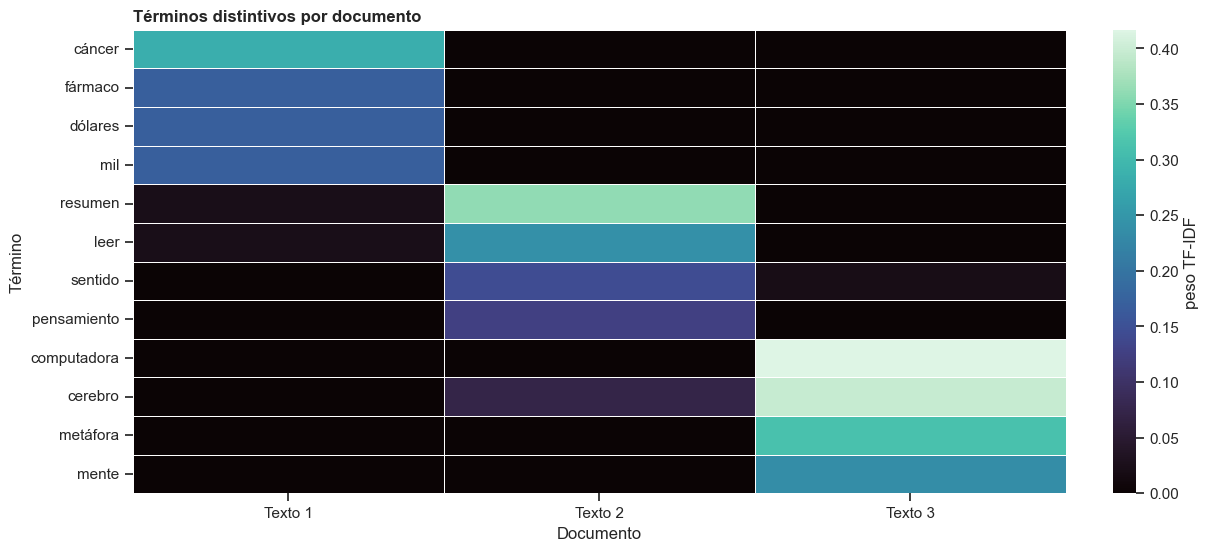

In [19]:
# Seleccionamos los términos más distintivos para construir un mapa de calor legible
terminos_heatmap = []

for i in range(len(nombres_unidades)):
    unidad = nombres_unidades[i]
    mascara_unidad = top_tfidf["unidad"] == unidad
    tabla_tfidf_unidad = top_tfidf[mascara_unidad]
    tabla_tfidf_unidad = tabla_tfidf_unidad.sort_values("rango", ascending=True)
    tabla_tfidf_unidad = tabla_tfidf_unidad.head(TOP_N_HEATMAP)

    for j in range(len(tabla_tfidf_unidad)):
        termino = tabla_tfidf_unidad.iloc[j]["termino"]
        if termino not in terminos_heatmap:
            terminos_heatmap.append(termino)

matriz_heatmap = tabla_tfidf[terminos_heatmap].T

alto_grafico = len(terminos_heatmap) * 0.45
if alto_grafico < 4:
    alto_grafico = 4

fig, ax = plt.subplots(figsize=(12, alto_grafico), constrained_layout=True)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Términos distintivos por documento", loc="left", fontweight="bold")
ax.set_xlabel("Documento")
ax.set_ylabel("Término")
plt.show()


El heatmap concentra bien la idea central de esta sección: cada documento tiene un pequeño grupo de términos que se vuelve más intenso cuando el algoritmo detecta que ahí son especialmente representativos.

Eso no equivale a interpretación automática. Lo que sí hace es orientarte hacia los lugares del corpus donde conviene volver a leer de cerca.


## 8. Del patrón al fragmento

Hasta acá trabajamos con tablas, conteos y pesos. Ahora hacemos el movimiento más importante del cuaderno: **volver al texto**.

Vamos a tomar el término `TF-IDF` más distintivo de cada documento y a buscar un fragmento del original donde aparezca. Como el modelo se construyó sobre lemas, usamos `spaCy` otra vez para encontrar una coincidencia compatible con ese lema dentro del texto crudo.


In [20]:
def extraer_fragmento_por_lemma(texto_original, termino_objetivo, ventana=140):
    """Busca un término por lema y devuelve un fragmento del texto original."""
    doc = nlp(texto_original)

    for token in doc:
        lema_token = normalizar_lemma(token)
        forma_token = token.text.lower()

        if lema_token == termino_objetivo or forma_token == termino_objetivo:
            inicio = token.idx - ventana
            if inicio < 0:
                inicio = 0

            fin = token.idx + len(token.text) + ventana
            if fin > len(texto_original):
                fin = len(texto_original)

            fragmento = texto_original[inicio:fin].strip()

            if inicio > 0:
                fragmento = "..." + fragmento
            if fin < len(texto_original):
                fragmento = fragmento + "..."

            return fragmento

    return "No se encontró una aparición clara de ese lema en el texto original."


# Nos quedamos con el término de rango 1 en cada documento
mascara_primer_rango = top_tfidf["rango"] == 1
tabla_terminos_retorno = top_tfidf[mascara_primer_rango].reset_index(drop=True)

registros_fragmentos = []
for i in range(len(tabla_terminos_retorno)):
    unidad = tabla_terminos_retorno.at[i, "unidad"]
    termino = tabla_terminos_retorno.at[i, "termino"]

    indice_documento = None
    for j in range(len(tabla_corpus)):
        unidad_actual = tabla_corpus.at[j, "titulo_corto"]
        if unidad_actual == unidad:
            indice_documento = j
            break

    titulo_original = tabla_corpus.at[indice_documento, "titulo"]
    texto_original = tabla_corpus.at[indice_documento, "texto"]
    fragmento = extraer_fragmento_por_lemma(texto_original, termino, ventana=VENTANA_FRAGMENTO)

    registro_fragmento = {
        "documento": unidad,
        "titulo": titulo_original,
        "termino_tfidf": termino,
        "fragmento": fragmento,
    }
    registros_fragmentos.append(registro_fragmento)

tabla_fragmentos = pd.DataFrame(registros_fragmentos)
display(tabla_fragmentos)


,documento,titulo,termino_tfidf,fragmento
0,Texto 1,"No, ChatGPT no hizo una vacuna contra el cáncer",cáncer,"...ales usamos ChatGPT para escribir un correo o resumir lo que nos da fiaca leer, un emprendedor tecnológico australiano lo usó para curar el cáncer de su ..."
1,Texto 2,Te lo resumo así nomás: cuando la IA no ayuda,resumen,...cula que “ahorre” el esfuerzo de leer el libro no queda alternativa más que enfrentarlo o bien buscar si algún alma caritativa dejó un buen resumen en Wi...
2,Texto 3,El cerebro tal vez no sea una computadora,computadora,...no su ingenio— y lo ridículas que nos resultan a la vista de nuestra mejor evidencia actual. Pero cuando se menciona que el cerebro es una computadora no...


In [21]:
print(tabla_corpus.at[0, "texto"])

Mientras los simples mortales usamos ChatGPT para escribir un correo o resumir lo que nos da fiaca leer, un emprendedor tecnológico australiano lo usó para curar el cáncer de su perro.
La historia circuló rápidamente impulsada por los férreos creyentes del potencial disruptivo de la inteligencia artificial para el avance de la ciencia. Greg Brockman —cofundador de OpenAI y, junto a Sam Altman, uno de los dos únicos fundadores que permanecen aún en la organización— primero compartió la noticia y luego la enmarcó dentro de la narrativa favorita de Silicon Valley, una que gira en torno al inminente advenimiento de la “inteligencia artificial general”, retuiteando un resumen que concluía “un hombre con un chatbot y 3.000 dólares acaban de superar toda la cadena de descubrimiento farmacéutico”. Fascinante. Y falso.
Originalmente publicada por The Australian, esta historia tiene todo lo que quieren los clics: Paul Conyngham adoptó a su perrita Rosie en 2019 justo antes de la pandemia y cuand

Este es el punto en el que la lectura distante se vuelve útil de verdad: no porque reemplace la interpretación, sino porque te devuelve al texto con una hipótesis mejor orientada. El término distintivo funciona como una pista. El fragmento te dice si esa pista sostiene, matiza o complica la primera intuición.


## 9. Límites del método

Conviene cerrar este recorrido con algunas advertencias metodológicas:

- trabajamos con un corpus pequeño, así que no conviene sobregeneralizar;
- `spaCy` ayuda mucho, pero no resuelve todo: la lematización y las entidades pueden fallar;
- `TF-IDF` detecta **distintividad léxica**, no interpretación discursiva completa;
- una palabra frecuente o distintiva no alcanza, por sí sola, para sostener una lectura fuerte;
- por eso la vuelta al fragmento no es un adorno final: es una parte constitutiva del método.


## Actividad breve

Escribí una celda Markdown nueva y respondé estas preguntas:

1. Elegí un término `TF-IDF` distintivo de uno de los documentos.
2. Explicá por qué ese término parece importante en la tabla.
3. Volvé al fragmento correspondiente y describí qué agrega el contexto.
4. Anotá una cosa que **no** habrías visto si te quedabas solo con el gráfico o con la tabla.
 Respuestas:
 1-Elijo el termino "cáncer" del texto 1.
 2-Ese termino es importante porque presenta un alto valor de TF-IDF, es decir que aparece con masmayor frecuencia en el texto 1 y es poco comun en los otros textos, lo vuelve distintivo dentro del corpus.
 3-El contexto agrega que el término ‘cáncer’ no se usa solo para hablar de la enfermedad, sino que aparece dentro de una crítica al uso de la inteligencia artificial, mostrando que no puede reemplazar completamente a un médico y que sus resultados pueden ser exagerados.
 4-Si me quedaba solo con el grafico o la tabla, solo hubiera visto que el termino cáncer es importante, pero no podia saber que el texto 1 estaba haciendo una critica al uso de la IA en la medicina.Eso solo se entiende si se lee todo el fragmento.

## Cierre

En este cuaderno recorriste un pipeline completo de análisis textual:

- adquisición de textos;
- procesamiento con `spaCy`;
- construcción de observables lingüísticos;
- paso a matrices sparse;
- lectura de `TF-IDF`;
- y regreso al fragmento.

Ese recorrido no reemplaza los trabajos integradores, pero sí te deja una base metodológica clara para encararlos con más criterio: corpus pequeño, decisiones explícitas, visualización sobria y lectura cercana sostenida por evidencia intermedia.
